# <div align="center"><u>The colon-kidney dataset</u>

## - General description of the colon-kidney dataset:

The [Colon-Kidney Dataset](https://www.openml.org/search?type=data&status=active&id=1137&sort=runs) is a OpenML dataset. It consists of 2 classes with a total of 546 instances. Specifically, 286 samples refer to colon cancerous tissue and 260 refer to kidney canerous tissue. The dimensionality of the dataset is 10936 features (gene expressions) per sample.

##############################################################################################################################

###  Import some useful libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Suppress warnings

In [2]:
# import warnings

# # To suppress all warnings
# warnings.filterwarnings("ignore")

### Load the colon-kidney dataset and store it within a pandas DataFrame

In [3]:
# Load the dataset and store it withina  panda dataframe to handle it easier
df = pd.read_csv(r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\The colon-kidney dataset.csv")

# Print the dataset
df

,id,ID_REF,1007_s_at,121_at,1405_i_at,1438_at,1487_at,1494_f_at,1552256_a_at,1552257_a_at,...,AFFX-r2-Ec-bioC-3_at,AFFX-r2-Ec-bioC-5_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,Tissue
0,1,203679,2883.2,2109.1,702.0,114.4,822.2,235.1,3346.1,815.1,...,2035.7,1908.1,30396.7,28371.7,85830.1,57084.9,3651.2,1736.1,2411.6,Kidney
1,2,179949,2607.4,1204.2,228.0,19.2,1497.1,167.6,23003.6,948.6,...,3811.6,3012.0,16748.8,13581.2,53322.5,37139.5,1648.1,502.9,890.6,Kidney
2,3,76558,2736.8,3912.2,1020.8,39.0,574.9,448.9,1337.9,605.6,...,17154.4,14835.5,64597.8,59311.2,203060.6,146422.6,3346.4,673.2,1499.3,Kidney
3,4,203712,1471.6,1318.2,4564.6,9.4,1426.5,105.2,2594.3,929.8,...,12382.2,11300.8,58551.7,49073.6,119460.8,95682.3,2553.5,961.2,1468.4,Kidney
4,5,102522,3564.7,2535.6,944.1,40.0,734.2,651.0,1490.5,712.3,...,13321.1,12966.9,54572.5,51049.1,178178.2,129533.2,3399.1,1209.8,1981.6,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,542,203733,3197.8,713.4,191.1,747.0,1597.8,179.5,1717.2,2261.2,...,1752.1,1494.9,22165.4,20442.0,65246.8,46710.2,2057.3,810.0,1338.2,Colon
542,543,76548,2161.9,1244.3,2347.0,1995.6,697.8,194.6,508.4,1042.5,...,5334.5,4588.2,21225.6,20067.2,80607.7,60204.9,1116.3,432.8,744.5,Colon
543,544,203731,4105.2,664.4,445.2,7008.2,1887.0,204.0,1951.8,2540.1,...,1511.6,1318.0,19659.4,15774.8,56065.6,43347.8,1191.2,371.3,688.5,Colon
544,545,152799,4204.7,894.2,102.8,1374.8,2891.5,306.2,1397.9,2072.4,...,7192.6,6375.2,34393.5,29137.7,89215.2,71290.1,1878.7,1009.7,1126.6,Colon


### Print dataset's general info

In [4]:
# Print general info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Columns: 10938 entries, id to Tissue
dtypes: float64(10935), int64(2), object(1)
memory usage: 45.6+ MB


### Check for missing values

In [5]:
# Check for missing values
df.isnull().any()

id                     False
ID_REF                 False
1007_s_at              False
121_at                 False
1405_i_at              False
                       ...  
AFFX-r2-P1-cre-5_at    False
AFFX-ThrX-3_at         False
AFFX-ThrX-5_at         False
AFFX-ThrX-M_at         False
Tissue                 False
Length: 10938, dtype: bool

### Find the number of columns with missing values

In [6]:
# Check if there are any columns with missing values
if df.isnull().any().sum() == 0:
    print("There are no columns with missing values")
else:
    print("There are columns with missing values. Proceed in deeper search to find them")

There are no columns with missing values


### Check for duplicates

In [7]:
# Check for duplicates
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
541    False
542    False
543    False
544    False
545    False
Length: 546, dtype: bool

### Find the number of duplicates and if they exist, drop them

In [8]:
# If duplicates exst, drop them
if df.duplicated().sum() == 0:
    print("There are no duplicates in the dataset")
else:
    print("There are duplicates in the dataset that need to be dropped")
    print()
    df.drop_duplicates()
    print("Duplicates have been successfully dropped")

There are no duplicates in the dataset


### Drop the 'id' column since it appears to be unnecessary

In [9]:
# Drop the "id" column
df = df.drop("id", axis = 1)

# Print the dataframe
df

,ID_REF,1007_s_at,121_at,1405_i_at,1438_at,1487_at,1494_f_at,1552256_a_at,1552257_a_at,1552274_at,...,AFFX-r2-Ec-bioC-3_at,AFFX-r2-Ec-bioC-5_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,Tissue
0,203679,2883.2,2109.1,702.0,114.4,822.2,235.1,3346.1,815.1,233.3,...,2035.7,1908.1,30396.7,28371.7,85830.1,57084.9,3651.2,1736.1,2411.6,Kidney
1,179949,2607.4,1204.2,228.0,19.2,1497.1,167.6,23003.6,948.6,414.1,...,3811.6,3012.0,16748.8,13581.2,53322.5,37139.5,1648.1,502.9,890.6,Kidney
2,76558,2736.8,3912.2,1020.8,39.0,574.9,448.9,1337.9,605.6,176.8,...,17154.4,14835.5,64597.8,59311.2,203060.6,146422.6,3346.4,673.2,1499.3,Kidney
3,203712,1471.6,1318.2,4564.6,9.4,1426.5,105.2,2594.3,929.8,240.4,...,12382.2,11300.8,58551.7,49073.6,119460.8,95682.3,2553.5,961.2,1468.4,Kidney
4,102522,3564.7,2535.6,944.1,40.0,734.2,651.0,1490.5,712.3,632.7,...,13321.1,12966.9,54572.5,51049.1,178178.2,129533.2,3399.1,1209.8,1981.6,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,203733,3197.8,713.4,191.1,747.0,1597.8,179.5,1717.2,2261.2,305.5,...,1752.1,1494.9,22165.4,20442.0,65246.8,46710.2,2057.3,810.0,1338.2,Colon
542,76548,2161.9,1244.3,2347.0,1995.6,697.8,194.6,508.4,1042.5,729.7,...,5334.5,4588.2,21225.6,20067.2,80607.7,60204.9,1116.3,432.8,744.5,Colon
543,203731,4105.2,664.4,445.2,7008.2,1887.0,204.0,1951.8,2540.1,259.2,...,1511.6,1318.0,19659.4,15774.8,56065.6,43347.8,1191.2,371.3,688.5,Colon
544,152799,4204.7,894.2,102.8,1374.8,2891.5,306.2,1397.9,2072.4,474.0,...,7192.6,6375.2,34393.5,29137.7,89215.2,71290.1,1878.7,1009.7,1126.6,Colon


### Drop the 'ID_REF' column since it appears to be unnecessary

In [10]:
# Drop the "ID_REF" column
df = df.drop("ID_REF", axis = 1)

# Print the dataframe
df

,1007_s_at,121_at,1405_i_at,1438_at,1487_at,1494_f_at,1552256_a_at,1552257_a_at,1552274_at,1552275_s_at,...,AFFX-r2-Ec-bioC-3_at,AFFX-r2-Ec-bioC-5_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,Tissue
0,2883.2,2109.1,702.0,114.4,822.2,235.1,3346.1,815.1,233.3,218.4,...,2035.7,1908.1,30396.7,28371.7,85830.1,57084.9,3651.2,1736.1,2411.6,Kidney
1,2607.4,1204.2,228.0,19.2,1497.1,167.6,23003.6,948.6,414.1,124.1,...,3811.6,3012.0,16748.8,13581.2,53322.5,37139.5,1648.1,502.9,890.6,Kidney
2,2736.8,3912.2,1020.8,39.0,574.9,448.9,1337.9,605.6,176.8,411.9,...,17154.4,14835.5,64597.8,59311.2,203060.6,146422.6,3346.4,673.2,1499.3,Kidney
3,1471.6,1318.2,4564.6,9.4,1426.5,105.2,2594.3,929.8,240.4,139.0,...,12382.2,11300.8,58551.7,49073.6,119460.8,95682.3,2553.5,961.2,1468.4,Kidney
4,3564.7,2535.6,944.1,40.0,734.2,651.0,1490.5,712.3,632.7,185.0,...,13321.1,12966.9,54572.5,51049.1,178178.2,129533.2,3399.1,1209.8,1981.6,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,3197.8,713.4,191.1,747.0,1597.8,179.5,1717.2,2261.2,305.5,181.8,...,1752.1,1494.9,22165.4,20442.0,65246.8,46710.2,2057.3,810.0,1338.2,Colon
542,2161.9,1244.3,2347.0,1995.6,697.8,194.6,508.4,1042.5,729.7,537.2,...,5334.5,4588.2,21225.6,20067.2,80607.7,60204.9,1116.3,432.8,744.5,Colon
543,4105.2,664.4,445.2,7008.2,1887.0,204.0,1951.8,2540.1,259.2,239.5,...,1511.6,1318.0,19659.4,15774.8,56065.6,43347.8,1191.2,371.3,688.5,Colon
544,4204.7,894.2,102.8,1374.8,2891.5,306.2,1397.9,2072.4,474.0,316.3,...,7192.6,6375.2,34393.5,29137.7,89215.2,71290.1,1878.7,1009.7,1126.6,Colon


### Create a bar chart based on the amount of "Tissue" column, to get a general overview of the dataset

The number of colon cancer occurrences is: 286
The number of kidney cancer occurrences is: 260


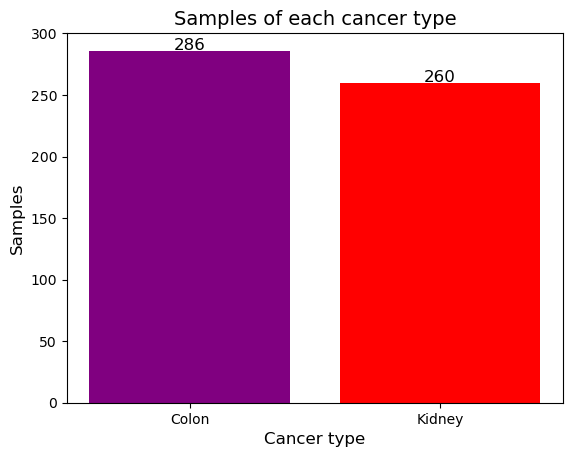

In [11]:
# Count the occurrences of each unique value in the 'Tissue' column
colon_count = df["Tissue"].eq("Colon").sum()
kidney_count = df["Tissue"].eq("Kidney").sum()

print("The number of colon cancer occurrences is:", colon_count)
print("The number of kidney cancer occurrences is:", kidney_count)

x = ["Colon", "Kidney"]
y = [colon_count, kidney_count]
colors = ["purple", "red"]

# Create a bar plot
plt.bar(x, y, color=colors)

# Add title and labels and title
plt.title("Samples of each cancer type", fontsize = 14)
plt.xlabel("Cancer type", fontsize = 12)
plt.ylabel("Samples", fontsize = 12)

# Display the count above each bar
for i, v in enumerate(y):
    plt.text(i, v + 1, str(v), ha="center", fontsize=12)

# Display the plot
plt.show()

### Create a pie chart based on the amount of "Tissue" column, to get a general overview of the dataset

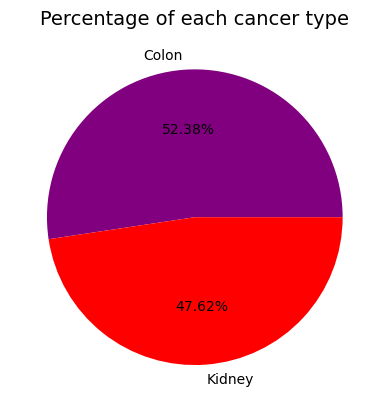

In [12]:
# Create a pie chart
plt.pie(y, labels=x, colors=colors, autopct="%.2f%%")

# Add a title
plt.title("Percentage of each cancer type", fontsize=14)

# Display the plot
plt.show()

### Map the cancerous tissue type to numerical values and create the "Target" column to comply with machine learning terminology.

In [13]:
# Map "Tissue" to numerical values and insert as "Target" before "Tissue"
df.insert(len(df.columns) - 1, "Target", df["Tissue"].map({"Kidney": 0, "Colon": 1}))

df

,1007_s_at,121_at,1405_i_at,1438_at,1487_at,1494_f_at,1552256_a_at,1552257_a_at,1552274_at,1552275_s_at,...,AFFX-r2-Ec-bioC-5_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,Target,Tissue
0,2883.2,2109.1,702.0,114.4,822.2,235.1,3346.1,815.1,233.3,218.4,...,1908.1,30396.7,28371.7,85830.1,57084.9,3651.2,1736.1,2411.6,0,Kidney
1,2607.4,1204.2,228.0,19.2,1497.1,167.6,23003.6,948.6,414.1,124.1,...,3012.0,16748.8,13581.2,53322.5,37139.5,1648.1,502.9,890.6,0,Kidney
2,2736.8,3912.2,1020.8,39.0,574.9,448.9,1337.9,605.6,176.8,411.9,...,14835.5,64597.8,59311.2,203060.6,146422.6,3346.4,673.2,1499.3,0,Kidney
3,1471.6,1318.2,4564.6,9.4,1426.5,105.2,2594.3,929.8,240.4,139.0,...,11300.8,58551.7,49073.6,119460.8,95682.3,2553.5,961.2,1468.4,0,Kidney
4,3564.7,2535.6,944.1,40.0,734.2,651.0,1490.5,712.3,632.7,185.0,...,12966.9,54572.5,51049.1,178178.2,129533.2,3399.1,1209.8,1981.6,0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,3197.8,713.4,191.1,747.0,1597.8,179.5,1717.2,2261.2,305.5,181.8,...,1494.9,22165.4,20442.0,65246.8,46710.2,2057.3,810.0,1338.2,1,Colon
542,2161.9,1244.3,2347.0,1995.6,697.8,194.6,508.4,1042.5,729.7,537.2,...,4588.2,21225.6,20067.2,80607.7,60204.9,1116.3,432.8,744.5,1,Colon
543,4105.2,664.4,445.2,7008.2,1887.0,204.0,1951.8,2540.1,259.2,239.5,...,1318.0,19659.4,15774.8,56065.6,43347.8,1191.2,371.3,688.5,1,Colon
544,4204.7,894.2,102.8,1374.8,2891.5,306.2,1397.9,2072.4,474.0,316.3,...,6375.2,34393.5,29137.7,89215.2,71290.1,1878.7,1009.7,1126.6,1,Colon


### Export the dataset to .csv file

In [14]:
# Export to .csv file
file_path = r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\The colon-kidney final dataset.csv"
df.to_csv(file_path, index=False)

print(f"CSV file saved at: {file_path}")

CSV file saved at: C:\Users\user\Desktop\AUTH\Διπλωματική\Python\The colon-kidney final dataset.csv


### Transform outliers

In [15]:
# Function that tranforms outliers given a dataframe
def cap_outliers_iqr(df, threshold=1.5):
    df_capped = df.copy()
    for col in df.columns:
        if col in df_capped.columns and pd.api.types.is_numeric_dtype(df_capped[col]):
            Q1 = df_capped[col].quantile(0.25)
            Q3 = df_capped[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR

            df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
            df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])
        else:
            print(f"Warning: Column '{col}' not found or is not numeric. Skipping.")
    return df_capped

In [16]:
# Transform outliers
df_capped = cap_outliers_iqr(df)
df_capped

,1007_s_at,121_at,1405_i_at,1438_at,1487_at,1494_f_at,1552256_a_at,1552257_a_at,1552274_at,1552275_s_at,...,AFFX-r2-Ec-bioC-5_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,Target,Tissue
0,2883.2,2109.1,702.0,114.4000,822.2000,235.1,3346.1,815.1,233.3,218.4,...,1908.1,30396.7,28371.7,85830.1,57084.9,3651.2,1736.1,2411.6,0.0,Kidney
1,2607.4,1204.2,228.0,19.2000,1497.1000,167.6,4219.2,948.6,414.1,124.1,...,3012.0,16748.8,13581.2,53322.5,37139.5,1648.1,502.9,890.6,0.0,Kidney
2,2736.8,3912.2,1020.8,39.0000,574.9000,448.9,1337.9,605.6,176.8,411.9,...,14835.5,64597.8,59311.2,203060.6,146422.6,3346.4,673.2,1499.3,0.0,Kidney
3,1471.6,1318.2,2567.6,9.4000,1426.5000,105.2,2594.3,929.8,240.4,139.0,...,11300.8,58551.7,49073.6,119460.8,95682.3,2553.5,961.2,1468.4,0.0,Kidney
4,3564.7,2535.6,944.1,40.0000,734.2000,523.3,1490.5,712.3,632.7,185.0,...,12966.9,54572.5,51049.1,178178.2,129533.2,3399.1,1209.8,1981.6,0.0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,3197.8,713.4,191.1,747.0000,1597.8000,179.5,1717.2,2261.2,305.5,181.8,...,1494.9,22165.4,20442.0,65246.8,46710.2,2057.3,810.0,1338.2,1.0,Colon
542,2161.9,1244.3,2347.0,1807.5125,697.8000,194.6,508.4,1042.5,729.7,537.2,...,4588.2,21225.6,20067.2,80607.7,60204.9,1116.3,432.8,744.5,1.0,Colon
543,4105.2,664.4,445.2,1807.5125,1887.0000,204.0,1951.8,2540.1,259.2,239.5,...,1318.0,19659.4,15774.8,56065.6,43347.8,1191.2,371.3,688.5,1.0,Colon
544,4204.7,894.2,102.8,1374.8000,2559.3125,306.2,1397.9,2072.4,474.0,316.3,...,6375.2,34393.5,29137.7,89215.2,71290.1,1878.7,1009.7,1126.6,1.0,Colon


### Check if "Transform Outliers" worked: Count how many elements are different between dataframes. If 0 nothing happened

In [17]:
# Compare element-wise and count differences
num_differences = (df != df_capped).sum().sum()

# Print results
if num_differences > 0:
    print(f"The tranformation of outliers worked. The amount of outliers that has been transformed is: {num_differences}")
else:
    print("No values transformed during outliers transformation phase")

The tranformation of outliers worked. The amount of outliers that has been transformed is: 253930


### Export the dataset to .csv file

In [18]:
# Export to .csv file
file_path = r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\The colon-kidney capped dataset.csv"
df_capped.to_csv(file_path, index=False)

print(f"CSV file saved at: {file_path}")

CSV file saved at: C:\Users\user\Desktop\AUTH\Διπλωματική\Python\The colon-kidney capped dataset.csv
